# Heralded photon subtraction

Compare a physical one-photon tap probability with its analytical value.

A vacuum beamsplitter tap followed by one detected photon implements an attenuated subtraction Kraus map. It approaches ideal subtraction only in the weak-tap limit.

In [1]:
!git clone https://github.com/chinmoybiswasdeep/PhotoGraphiQ.git
%cd ./PhotoGraphiQ
!python -m pip install '.[visualization]'

Cloning into 'PhotoGraphiQ'...
remote: Enumerating objects: 886, done.
remote: Counting objects: 100% (886/886), done.
remote: Compressing objects: 100% (562/562), done.
remote: Total 886 (delta 371), reused 803 (delta 292), pack-reused 0 (from 0)
Receiving objects: 100% (886/886), 5.68 MiB | 35.25 MiB/s, done.
Resolving deltas: 100% (371/371), done.
/content/PhotoGraphiQ
Processing /content/PhotoGraphiQ
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 5.3 MB/s eta 0:00:00
  Created wheel for photographiq: filename=photographiq-0.3.1-py3-none-any.whl size=89802 sha256=56d1294144b35d08a4b88acb85553c83b498bda51ae94ed83234ce1de76fe6c9
  Stored in d

Number of logical modes: 5
Number of source operations: 10

Source operations:
 0: R               modes = (0,)
 1: S               modes = (0,)
 2: cz              modes = (0, 1)
 3: R               modes = (1,)
 4: cz              modes = (1, 2)
 5: S               modes = (2,)
 6: cz              modes = (2, 3)
 7: R               modes = (3,)
 8: cubic_phase     modes = (4,)
 9: cz              modes = (3, 4)

MBQC measurements generated by each operation:
 0: (2, 6, 10, 14)
 1: (18, 22, 26, 30, 34)
 2: (39, 43, 47, 51, 55, 59, 63, 67)
 3: (71, 75, 79, 83)
 4: (88, 92, 96, 100, 104, 108, 112, 116)
 5: (120, 124, 128, 132, 136)
 6: (141, 145, 149, 153, 157, 161, 165, 169)
 7: (173, 177, 181, 185)
 8: (191,)
 9: (197, 201, 205, 209, 213, 217, 221, 225)


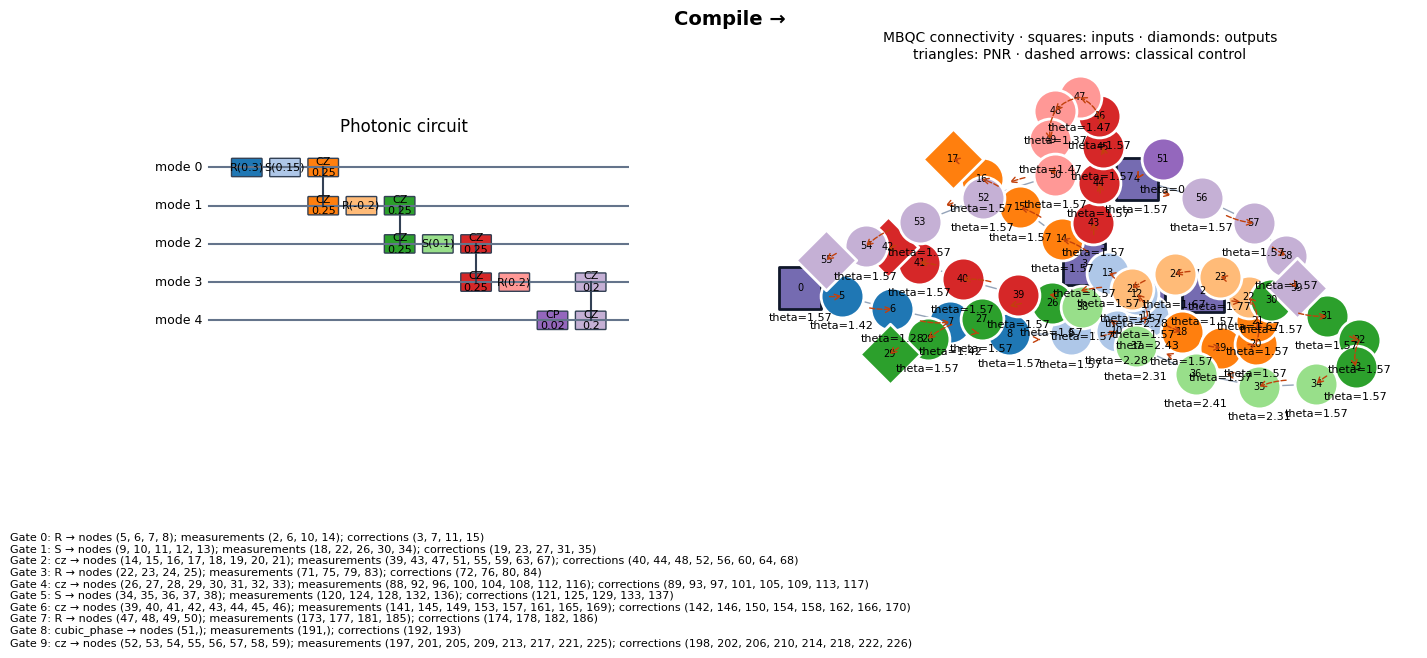

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import photographiq as pg


# ============================================================
# 1. Five-mode photonic circuit
#    Modes 0-3: Gaussian operations
#    Mode 4: one non-Gaussian cubic-phase operation
# ============================================================

circuit = (
    pg.Circuit(5)

    # ---------------- Gaussian operations ----------------

    # Mode 0
    .rotate(0, 0.30)
    .squeeze(0, 0.15)

    # Connect mode 0 -> mode 1
    .cz(0, 1, 0.25)

    # Mode 1
    .rotate(1, -0.20)

    # Connect mode 1 -> mode 2
    .cz(1, 2, 0.25)

    # Mode 2
    .squeeze(2, 0.10)

    # Connect mode 2 -> mode 3
    .cz(2, 3, 0.25)

    # Mode 3
    .rotate(3, 0.20)

    # ---------------- Non-Gaussian operation ----------------

    # Only mode 4 is explicitly non-Gaussian
    .cubic_phase(4, 0.02)

    # Connect the non-Gaussian mode to the rest
    .cz(3, 4, 0.20)
)


# ============================================================
# 2. Compile ordinary circuit -> MBQC pattern
#
# Smaller squeezing is used here because a Fock simulation
# becomes expensive very quickly.
# ============================================================

pattern, trace = circuit.compile(
    squeezing=0.25,
    return_trace=True
)


# ============================================================
# 3. Print compilation information
# ============================================================

print("Number of logical modes:", 5)
print("Number of source operations:", len(trace.steps))

print("\nSource operations:")

for i, step in enumerate(trace.steps):

    print(
        f"{i:2d}: "
        f"{step.source_gate:15s} "
        f"modes = {step.source_modes}"
    )


print("\nMBQC measurements generated by each operation:")

for i, step in enumerate(trace.steps):

    print(
        f"{i:2d}: {step.measurements}"
    )


# ============================================================
# 4. Automatic visualization
#
# LEFT  : original photonic circuit
# RIGHT : MBQC implementation
#
# Nothing is manually drawn.
# ============================================================

pg.visualize_compilation(
    circuit,
    pattern,
    trace=trace
)

plt.show()

## Interpretation

One photon survives after one is detected from an initial two-photon state. The herald probability falls toward zero with the tap angle.

## Exercise

Sweep the tap angle and compare success probability with fidelity to normalized ideal subtraction for a cat input.